In [147]:
# import libraries 
import numpy as np  
import pandas as pd  
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_squared_error, r2_score  
from sklearn.model_selection import train_test_split

In [148]:
# import dataset
diamonds = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv')

In [149]:
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [150]:
# selecting numeric predictors
X = diamonds[['depth','carat','table']]
y = diamonds['price']
# table = width of the diamond

In [151]:
# Dividing the dataset into training and testing sets
# Random state for reproducibility
# 20% of the data will be used for testing,80% for training
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.2, random_state=7)

In [152]:
# Fitting the multiple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [153]:
# Model coefficients and intercepts
print("intercept:", model.intercept_)
print("coefficients:", model.coef_)
y_pred = model.predict(X_test)
y_pred
# y = b0 + b1x1 + b2x2 + .....bnxn
# b0 = intercept
# b1,b2,...bn = coefficients

intercept: 13291.276029163644
coefficients: [-155.95187797 7875.37847668 -104.58616105]


array([1856.82907649, 3809.26832209, 4664.57726025, ..., 1297.56201082,
       1609.55268792, 4597.61635553])

In [154]:
mse = mean_squared_error(y_test, y_pred) # don't over rely on the mse
r2 = r2_score(y_test, y_pred) # between 0 and 1, higher is better

print(mse)
print(r2)



2331889.7214656523
0.8508106300695077


## model explains 85% of the values

Text(0, 0.5, 'Predicted prices')

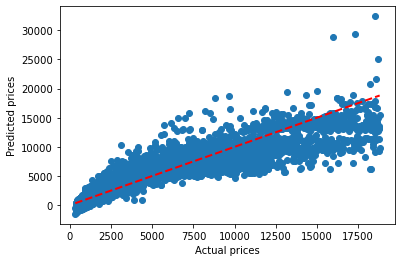

In [155]:
# Plotting the predicted vs actual values
import matplotlib.pyplot as plt 

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # line of perfect predictions
plt.xlabel('Actual prices')
plt.ylabel('Predicted prices')

In [156]:
rmse = np.sqrt(mse)
rmse


1527.052625637261

In [157]:
# mean absolute error
from sklearn.metrics import mean_absolute_error 
mae = mean_absolute_error(y_test, y_pred)
mae

999.0327626349077

## Dealing With Categorical Data/Variables
Using one-hot-encoding-makes sure each category is converted into a new binary column(dummy variable)

In [158]:
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [159]:
diamonds.color.value_counts()

G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: color, dtype: int64

In [160]:
diamonds.cut.value_counts()

Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: cut, dtype: int64

Limitation : Causes a dummy variable which causes multicollinearity

In [161]:
features = ['carat','cut','color','depth','table']
target = 'price'

In [162]:
x = diamonds[features]
y = diamonds[target]

In [163]:
# we need to convert the categorical variables into numeric variables before we can fit a linear regression model. We can use one-hot encoding for this purpose.
# drop_first=True will drop the first category of each categorical variable to avoid multicollinearity. This is because if we include all categories, one of them can be perfectly predicted from the others, which can cause issues in the regression model.
x_encoded = pd.get_dummies(x, drop_first=True)
x_encoded.head()

,carat,depth,table,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,color_E,color_F,color_G,color_H,color_I,color_J
0,0.23,61.5,55.0,0,1,0,0,1,0,0,0,0,0
1,0.21,59.8,61.0,0,0,1,0,1,0,0,0,0,0
2,0.23,56.9,65.0,1,0,0,0,1,0,0,0,0,0
3,0.29,62.4,58.0,0,0,1,0,0,0,0,0,1,0
4,0.31,63.3,58.0,1,0,0,0,0,0,0,0,0,1


In [164]:
# fitting the model 
X_train, X_test, y_train, y_test = train_test_split(x_encoded, y,  test_size=0.2, random_state=7)
model.fit(X_train, y_train)

LinearRegression()

In [165]:
model.intercept_

2587.4494640832454

In [166]:
model.coef_

array([ 8212.35396302,   -61.73350717,   -41.52983676,  1064.18933862,
        1574.50032972,  1306.53359905,  1371.20721132,   -98.21444059,
         -88.97888037,  -107.78840503,  -728.69519467, -1064.41020437,
       -1909.4555091 ])

In [167]:
import statsmodels.api as sm
X_train = sm.add_constant(X_train) # adding a constant
ols_model = sm.OLS(y_train, X_train).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                 2.260e+04
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:38:17   Log-Likelihood:            -3.7477e+05
No. Observations:               43152   AIC:                         7.496e+05
Df Residuals:                   43138   BIC:                         7.497e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          2587.4495    509.873      5.075

In [168]:
salary = pd.read_csv('salary.csv', encoding='utf-8-sig')

In [169]:
salary.head()

,"age,experience,education,city,gender,salary"
0,"25,2,Bachelors,Nairobi,Male,45000"
1,"28,4,Masters,Nairobi,Female,65000"
2,"35,10,PhD,Mombasa,Male,120000"
3,"30,6,Masters,Kisumu,Female,70000"
4,"40,15,PhD,Nairobi,Male,150000"


In [170]:
salary2 = pd.read_csv('salary2.csv')
salary2.head()

,"age,experience,education,city,gender,salary"
0,"25,2,Bachelors,Nairobi,Male,45000"
1,"28,4,Masters,Nairobi,Female,65000"
2,"35,10,PhD,Mombasa,Male,120000"
3,"30,6,Masters,Kisumu,Female,70000"
4,"40,15,PhD,Nairobi,Male,150000"


In [171]:
book3 = pd.read_excel('Book3.xlsx')
book3.head()

,"age,experience,education,city,gender,salary"
0,"25,2,Bachelors,Nairobi,Male,45000"
1,"28,4,Masters,Nairobi,Female,65000"
2,"35,10,PhD,Mombasa,Male,120000"
3,"30,6,Masters,Kisumu,Female,70000"
4,"40,15,PhD,Nairobi,Male,150000"


In [172]:
df = pd.DataFrame({
    "age": [25, 28, 35, 30, 40, 23, 32, 29, 45, 27,
            38, 31, 26, 34, 41, 36, 24, 33, 39, 28],

    "experience": [2, 4, 10, 6, 15, 1, 8, 5, 20, 3,
                   12, 7, 2, 9, 16, 11, 1, 8, 14, 4],

    "education": ["Bachelors", "Masters", "PhD", "Masters", "PhD",
                  "Bachelors", "Masters", "Bachelors", "PhD", "Bachelors",
                  "Masters", "Masters", "Bachelors", "PhD", "PhD",
                  "Masters", "Bachelors", "Masters", "PhD", "Bachelors"],

    "city": ["Nairobi", "Nairobi", "Mombasa", "Kisumu", "Nairobi",
             "Kisumu", "Mombasa", "Nairobi", "Nairobi", "Mombasa",
             "Kisumu", "Nairobi", "Kisumu", "Mombasa", "Nairobi",
             "Nairobi", "Mombasa", "Kisumu", "Nairobi", "Nairobi"],

    "gender": ["Male", "Female", "Male", "Female", "Male",
               "Female", "Male", "Female", "Male", "Female",
               "Male", "Female", "Male", "Female", "Female",
               "Male", "Male", "Female", "Male", "Female"],

    "salary": [45000, 65000, 120000, 70000, 150000,
               35000, 85000, 60000, 180000, 50000,
               95000, 78000, 42000, 110000, 155000,
               100000, 38000, 82000, 140000, 58000]
})

print(df.head())



   age  experience  education     city  gender  salary
0   25           2  Bachelors  Nairobi    Male   45000
1   28           4    Masters  Nairobi  Female   65000
2   35          10        PhD  Mombasa    Male  120000
3   30           6    Masters   Kisumu  Female   70000
4   40          15        PhD  Nairobi    Male  150000


In [173]:
features = ['age', 'experience', 'education', 'city', 'gender']
target = 'salary'

In [174]:
X = df[features]
y = df[target]

In [175]:
x_encoded = pd.get_dummies(X, drop_first=True)
x_encoded.head()

,age,experience,education_Masters,education_PhD,city_Mombasa,city_Nairobi,gender_Male
0,25,2,0,0,0,1,1
1,28,4,1,0,0,1,0
2,35,10,0,1,1,0,1
3,30,6,1,0,0,0,0
4,40,15,0,1,0,1,1


In [176]:
# Dividing the dataset into training and testing sets (20% test size, random state for reproducibility  )
X_train, X_test, y_train, y_test = train_test_split(x_encoded, y,  test_size=0.2, random_state=7)

In [177]:
mode12 = sm.OLS(y_train, sm.add_constant(X_train)).fit()
print(mode12.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     816.9
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           8.91e-11
Time:                        19:38:17   Log-Likelihood:                -140.95
No. Observations:                  16   AIC:                             297.9
Df Residuals:                       8   BIC:                             304.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.415e+05   3.58e+0

c:\Users\Lenovo\anaconda3\envs\learn-env\lib\site-packages\scipy\stats\stats.py:1603: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [178]:
import statsmodels.api as sm
# Load the dataset from the UCI repository
# Define column names as per the dataset's documentation
column_names = [
    'mpg', 'cylinders', 'displacement', 'horsepower',
    'weight', 'acceleration', 'model_year', 'origin', 'car_name']
    
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
df = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')

In [179]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [180]:
# Features and target variable
X_row = df[['cylinders', 'weight', 'model_year']]
y_row = df['mpg']

In [181]:
# Initialise a model and fit it
base_model = sm.OLS(y_row, sm.add_constant(X_row))
base_results = base_model.fit()
print(base_results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     552.4
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          9.90e-141
Time:                        19:38:19   Log-Likelihood:                -1054.3
No. Observations:                 398   AIC:                             2117.
Df Residuals:                     394   BIC:                             2132.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -13.9256      4.037     -3.449      0.0

In [182]:
# performing linear transformation
# converting the weight from pounds to kilograms
# 1 pound = 0.453592kg
x_metrics = X_row.copy() # create a copy of the original features to avoid modifying it
x_metrics['weight'] = x_metrics['weight'] * 0.453592

In [183]:
x_metrics.head()

,cylinders,weight,model_year
0,8,1589.386368,70
1,8,1675.115256,70
2,8,1558.542112,70
3,8,1557.181336,70
4,8,1564.438808,70


In [184]:
# Initialise a model and fit it
metrics_model = sm.OLS(y_row, sm.add_constant(x_metrics))
metrics_results = metrics_model.fit()
print(metrics_results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     552.4
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          9.90e-141
Time:                        19:38:19   Log-Likelihood:                -1054.3
No. Observations:                 398   AIC:                             2117.
Df Residuals:                     394   BIC:                             2132.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -13.9256      4.037     -3.449      0.0

In [186]:
print(base_results.params)
print(metrics_results.params)

const        -13.925603
cylinders     -0.087402
weight        -0.006511
model_year     0.753286
dtype: float64
const        -13.925603
cylinders     -0.087402
weight        -0.014354
model_year     0.753286
dtype: float64


In [187]:
# standardization of data sets
# standardize weight
from sklearn.preprocessing import StandardScaler, MinMaxScaler , Normalizer
scaler = StandardScaler()
X_std = scaler.fit_transform(X_row)


In [190]:
# Initialise the data set
std_model = sm.OLS(y_row, sm.add_constant(X_std))
std_model_results = std_model.fit()
print(std_model_results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     552.4
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          9.90e-141
Time:                        19:57:40   Log-Likelihood:                -1054.3
No. Observations:                 398   AIC:                             2117.
Df Residuals:                     394   BIC:                             2132.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.5146      0.172    136.433      0.0

<ipython-input-192-d9bf60773809>:5: RuntimeWarning: invalid value encountered in log
  y_log = np.log(y)


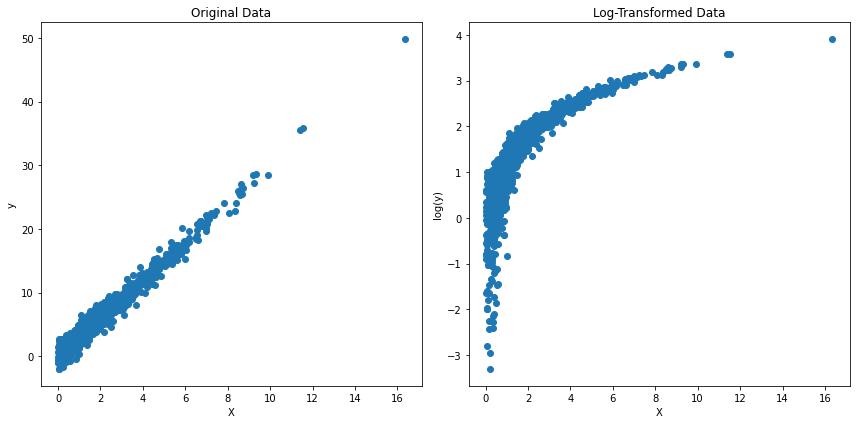

In [192]:
np.random.seed(42)
X = np.random.exponential(2, 1000)
y = 3 * X + np.random.normal(0, 1, 1000) # adding some noise to the data
# log transformation
y_log = np.log(y)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X, y)
plt.title("Original Data")
plt.xlabel("X")
plt.ylabel("y")
plt.subplot(1, 2, 2)
plt.scatter(X, y_log)
plt.title("Log-Transformed Data")
plt.xlabel("X")
plt.ylabel("log(y)")
plt.tight_layout()
plt.show()

In [193]:
# log transformation
X_log = X_row.copy()
X_log['log_weight'] = np.log(X_log['weight'])


In [194]:
# split data into training and testing sets
X_log[["weight", "log_weight"]]

,weight,log_weight
0,3504.0,8.161660
1,3693.0,8.214194
2,3436.0,8.142063
3,3433.0,8.141190
4,3449.0,8.145840
...,...,...
393,2790.0,7.933797
394,2130.0,7.663877
395,2295.0,7.738488
396,2625.0,7.872836


In [196]:
# initialise a model
weight_log_model = sm.OLS(y_row, sm.add_constant(X_log))
weight_log_results = weight_log_model.fit() 
base_results.rsquared, weight_log_results.rsquared

(0.8079312774585562, 0.850698633216329)